# Hourly Traffic Volume Prediction using Machine Learning

In [131]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [133]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [135]:
# Load Data Set
df = pd.read_csv("D:\\1.My Projects for DS\\UBER - Develop a predictive model to accurately forecast hourly traffic volumes at different road junctions based on historical traffic data\\Metro_Interstate_Traffic_Volume.csv")
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [139]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temp,48204.0,281.205870,13.338232,0.0,272.16,282.45,291.806,310.07
rain_1h,48204.0,0.334264,44.789133,0.0,0.00,0.00,0.000,9831.30
snow_1h,48204.0,0.000222,0.008168,0.0,0.00,0.00,0.000,0.51
clouds_all,48204.0,49.362231,39.015750,0.0,1.00,64.00,90.000,100.00
traffic_volume,48204.0,3259.818355,1986.860670,0.0,1193.00,3380.00,4933.000,7280.00


In [141]:
df.isnull().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [143]:
# Drop Holiday Column
df = df.drop(columns=['holiday'])

In [145]:
# Show column 
print(df.columns)


Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')


In [147]:
df.duplicated().sum()

17

In [149]:
# Remove duplicates
df = df.drop_duplicates()

In [151]:
# Create new Features
df['date_time'] = pd.to_datetime(df['date_time'])

# Hour of day (0–23)
df['hour'] = df['date_time'].dt.hour  

# Day of week (0=Monday, 6=Sunday)
df['day_of_week'] = df['date_time'].dt.dayofweek  

# Month
df['month'] = df['date_time'].dt.month  

# Weekend hai ya nahi
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)  


In [153]:
# Weather-based simplification:
df['is_rainy'] = df['weather_main'].apply(lambda x: 1 if x in ['Rain','Drizzle','Thunderstorm'] else 0)
df['is_snowy'] = df['snow_1h'].apply(lambda x: 1 if x > 0 else 0)


In [155]:
# Rush hour feature:
df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0)


In [157]:
df

,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month,is_weekend,is_rainy,is_snowy,is_rush_hour
0,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,0,0,0,1
1,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,0,0,0,0
2,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,0,0,0,0
3,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,0,0,0,0
4,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543,19,6,9,1,0,0,0
48200,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781,20,6,9,1,0,0,0
48201,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159,21,6,9,1,1,0,0
48202,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450,22,6,9,1,0,0,0


In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48187 entries, 0 to 48203
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   temp                 48187 non-null  float64       
 1   rain_1h              48187 non-null  float64       
 2   snow_1h              48187 non-null  float64       
 3   clouds_all           48187 non-null  int64         
 4   weather_main         48187 non-null  object        
 5   weather_description  48187 non-null  object        
 6   date_time            48187 non-null  datetime64[ns]
 7   traffic_volume       48187 non-null  int64         
 8   hour                 48187 non-null  int32         
 9   day_of_week          48187 non-null  int32         
 10  month                48187 non-null  int32         
 11  is_weekend           48187 non-null  int64         
 12  is_rainy             48187 non-null  int64         
 13  is_snowy             48187 non-null 

In [161]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
temp,48187.0,281.204995,0.0,272.16,282.45,291.806,310.07,13.338738
rain_1h,48187.0,0.334382,0.0,0.0,0.0,0.0,9831.3,44.797033
snow_1h,48187.0,0.000222,0.0,0.0,0.0,0.0,0.51,0.008169
clouds_all,48187.0,49.365451,0.0,1.0,64.0,90.0,100.0,39.015213
date_time,48187,2016-01-05 06:49:48.133729024,2012-10-02 09:00:00,2014-02-06 07:30:00,2016-06-10 21:00:00,2017-08-11 05:30:00,2018-09-30 23:00:00,NaN
traffic_volume,48187.0,3259.618134,0.0,1192.5,3379.0,4933.0,7280.0,1986.954465
hour,48187.0,11.397742,0.0,5.0,11.0,17.0,23.0,6.940373
day_of_week,48187.0,2.984913,0.0,1.0,3.0,5.0,6.0,2.006041
month,48187.0,6.50524,1.0,4.0,7.0,9.0,12.0,3.400285
is_weekend,48187.0,0.284309,0.0,0.0,0.0,1.0,1.0,0.451089


In [163]:
# Keep important columns for ML
features = ['temp','rain_1h','snow_1h','clouds_all','hour','day_of_week','month',
            'is_weekend','is_rainy','is_snowy','is_rush_hour']
target = 'traffic_volume'


# EDA

## 1>  Univariate Analysis

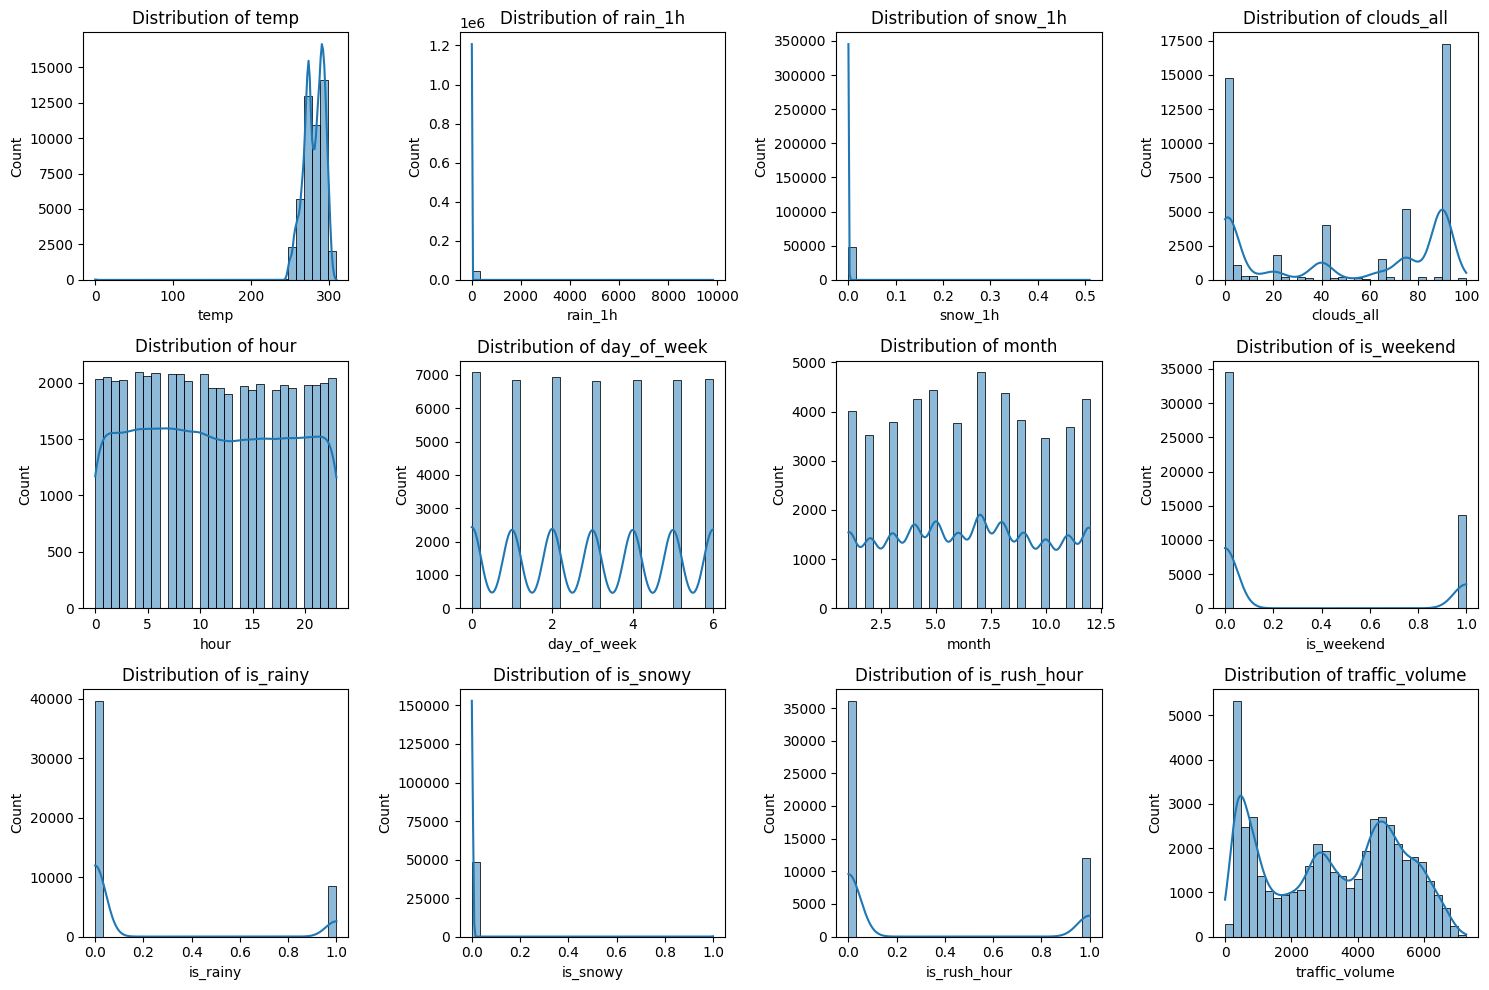

In [167]:
plt.figure(figsize=(15,10))
for i,col in enumerate(features + [target]):
    plt.subplot(3,4,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Univariate Analysis Insights


### 1> Distribution of Temperature (temp) (This Graph show That mostly Days in which Temprature)
- If the bar is tall at a certain temperature, it means there were more days with that temperature.
- Mostly between 272–292 K (normal range) means Most of the days were neither too hot nor too cold it is medium temperature (25-30C).

### 2> Distribution of Rain (rain_1h) (This Graph Shows that How much rain occurred every hour and how many times it happened.)
- If the bar is tall at 0 mm, it means that most of the time there was no rainfall.
- Mostly 0, but extreme outliers (9831 mm) → unrealistic means Rain occurs for a very short time, but when it does, it is heavy.

### 3> Distribution of Snow (snow_1h) (This Graph show that How much snow fell in each hour)
- If all the bars are small or at zero, then it means there is no snowfall.
- It is almost impossible for snow to fall at this place.

### 4> Distribution of Clouds (clouds_all) (This Graph is show that How much the sky was covered with clouds (0 = clear, 100 = fully covered).)
- If there are more bars in the 80–100% range, it means most of the days were cloudy.
- Spread across 0–100%, with peaks at clear and overcast means During the monsoon, the sky remains covered with clouds most of the time.
- Can affect traffic visibility.

### 5> Distribution of Hour of Day (hour) (This Graph show that At which hour of the day was the traffic highest?)
- So that which Hour has long Graph.
- Strong daily pattern, traffic depends on time means This graph shows that the data is unbiased and balanced — data for every hour is available, which allows for accurate comparison across the entire day.
- Very important predictor.

### 6> Distribution of Day of Week (This Graph Show That On which day of the week was the traffic highest?)
- All days balanced means  Counts are nearly equal across all days (0 to 6), indicating consistent activity throughout the week.
- Needed to capture weekday vs weekend difference.
- Cyclical Trend: The sinusoidal line suggests a periodic pattern—behavior or intensity varies rhythmically across days, even though total volume remains stable.

- 7> Distribution of Month (This Graph Show that How was the traffic in each month of the year?)
    - Covers all seasons means The bar heights are fairly consistent across all months, indicating that the overall activity remains stable throughout the year.
 
### 8> Distribution of Weekend (is_weekend) (This Graph show that Whether that day was a weekend or not.)
- The count of is_weekend = 0 (workdays) is very high, indicating that most of the data is based on workdays.
- The data is skewed towards weekdays compared to weekends, indicating that most activities or events occur on working days.

### 9> Distribution of Rainy(is_rainy) (This Graph Show that How many times did it rain?)
- So that is_rainy = 0 means Rain Free day and is_rainy = 1 means rainy day
- so there is show is_rainy = 0 bar is higher than is_rainy = 1 so that Which indicates that most days are rain-free.
- This variable takes only two values (0 and 1), clearly distinguishing between rain and no rain.

### 10> Distribution of Snowy (is_snowy) (This Graph Show that How many times did it snow?)
- The count of is_snowy = 0 is very high, indicating that most days had no snowfall.
- This variable takes only two values (0 and 1), clearly distinguishing between snowy and non-snowy days.

### 11> Distribution of Rush Hour (is_rush_hour) (This Graph show that How many times data was recorded during rush hours(Busy Time).)
- Most of the data has is_rush_hour = 0, indicating that the majority of activities do not occur during rush hours.
- This variable takes only two values (0 and 1), clearly distinguishing between rush hours and non-rush hours.

### 12> Distribution of Traffic Volume (Target) (This Graph Show that How many vehicles were on the road.)
- Several common traffic levels: The graph shows multiple peaks—especially around low volume, 3000, and 5000—indicating that traffic frequently occurs at these levels.
- Low traffic occurs most frequently: The highest peak is at a lower traffic volume, indicating that low traffic conditions happen most often.
- High variability in traffic: The spread of the graph and multiple peaks indicate that traffic volume varies considerably, i.e., it changes across different times or conditions.

## 2> Bivariate Analysis

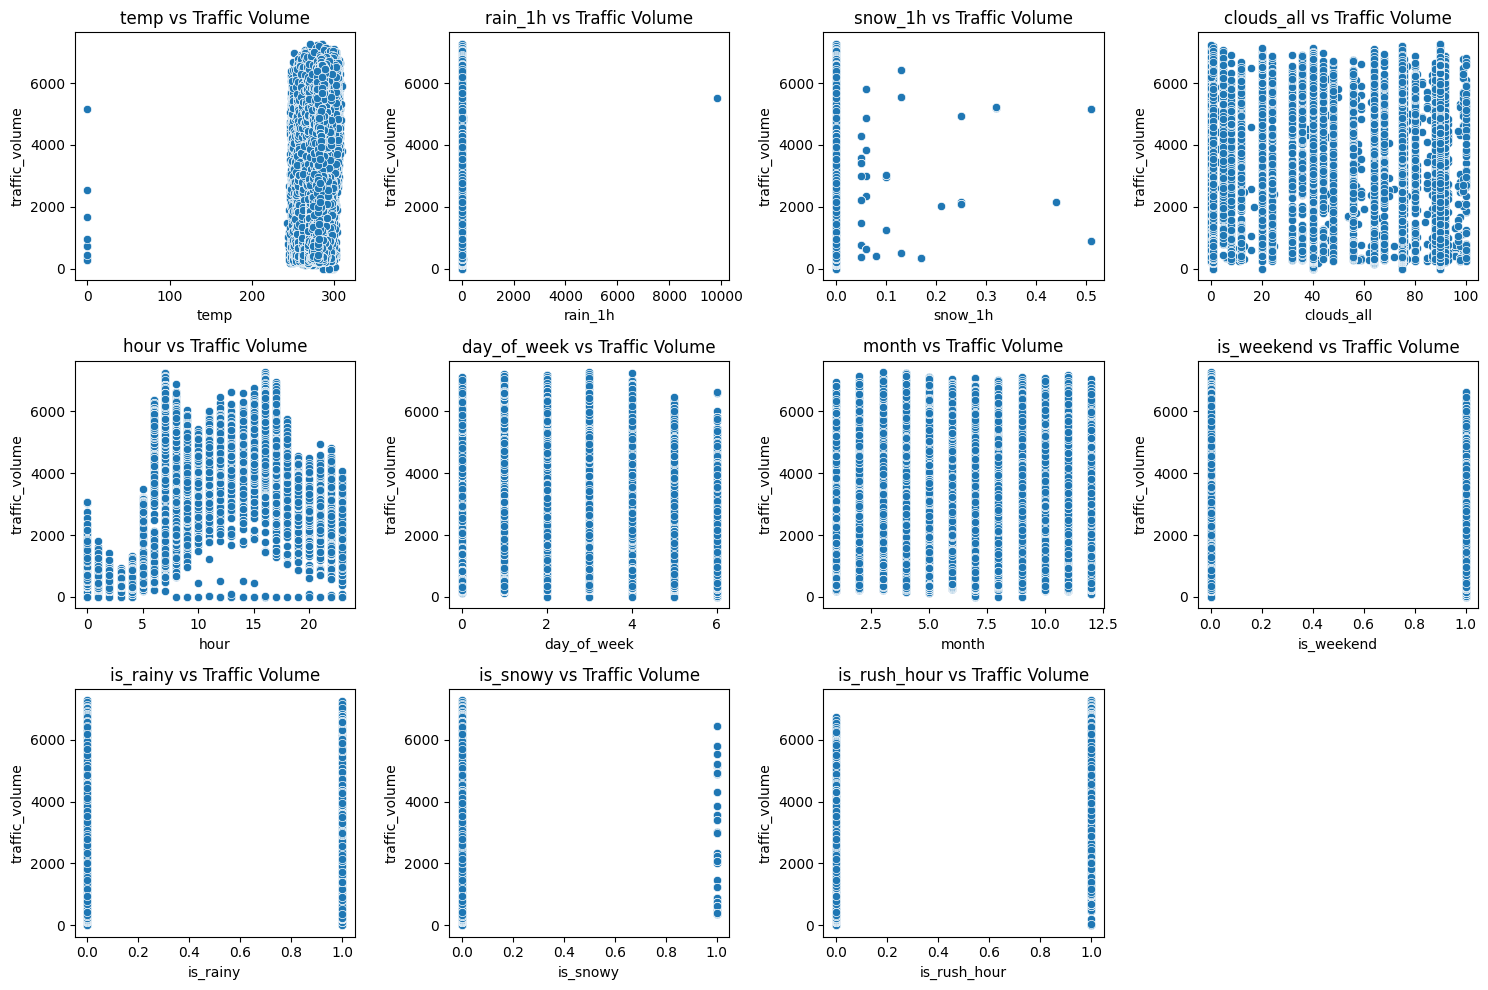

In [169]:
# (Feature vs Target)
plt.figure(figsize=(15,10))
for i,col in enumerate(features):
    plt.subplot(3,4,i+1)
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f'{col} vs Traffic Volume')
plt.tight_layout()
plt.show()

# Bivariate Analysis Insights


### 1> temp vs Traffic Volume
- This  scatter plot show That  shows the traffic volume at different temperatures.
- Most of the data is between 250 and 300 temperature units, indicating that traffic volume is mostly recorded within this temperature range.
- Even at the same temperature, traffic volume ranges from 0 to over 6000, indicating that traffic levels are not determined solely by temperature.
- "Very few data points are near 0 temperature, but even among them, traffic volume varies widely—indicating that traffic behavior can be unpredictable in extreme cold.


### 2> rain_1h vs Traffic Volume
- This  scatter plot show That Relationship between rainfall and traffic — how much it rained in an hour and the corresponding traffic volume.
- Most traffic occurs during low or no rainfall. Most data points are around rain_1h = 0, indicating that traffic volume is predominantly recorded during dry or lightly rainy conditions.
- Rainfall has a limited impact on traffic. Even during light rain, traffic volume does not decrease significantly, suggesting that rain does not greatly affect traffic flow.
- An unusual data point shows extremely high rainfall (~10,000 units) with traffic volume around 6000. This may be an outlier, possibly due to a data error or a special event.


### 3> snow_1h vs Traffic Volume
- This  scatter plot show That How traffic changes when it snows.
- Snowfall occurs very rarely. Most data points are around snow_1h = 0, indicating that snowfall is infrequent in the dataset.
- Even with minimal snowfall, traffic volume ranges from 0 to over 7000, suggesting that snow does not have a significant impact on traffic.
- No clear pattern is visible in the graph, indicating that there is no strong relationship between snowfall and traffic volume.


### 4> clouds_all vs Traffic Volume
- This  scatter plot show That Relationship between cloud cover and traffic.
- There is no clear relationship. Data points are spread across the entire cloud coverage range (0 to 100), indicating that cloudiness does not have a strong correlation with traffic volume.
- Traffic volume varies under all conditions, ranging from 0 to over 7000, suggesting that clouds do not significantly affect traffic.
- Traffic is observed across the entire x-axis, showing that it occurs under all levels of cloud cover, whether the sky is clear or fully overcast.


### 5> hour vs Traffic Volume
- This  scatter plot show That Traffic volume for each hour.
- Traffic peaks during rush hours — traffic volume increases in the morning (7–9 AM) and evening (4–6 PM), reflecting typical office or school timings.
- Traffic is low at night — from 12 AM to 5 AM, traffic volume is minimal, indicating reduced activity during these hours.
- Traffic remains moderate and stable from 10 AM to 3 PM, reflecting non-rush hour activity.


### 6> day_of_week vs Traffic Volume
- This  scatter plot show That On which day of the week traffic is higher or lower.
- Traffic volume is almost similar on all days (0 to 6). Data points are evenly distributed, indicating that there is no significant change in traffic on any single day.
- No clear weekly pattern is observed. There is no consistent rise or fall in traffic volume throughout the week, suggesting that traffic behavior remains relatively stable.
- Traffic volume varies each day, ranging from 0 to over 7000, indicating that traffic conditions can differ from day to day.

  
### 7> month vs Traffic Volume
- This  scatter plot show That Traffic volume across different months of the year.
- Traffic is fairly consistent throughout the year. Data is evenly distributed across months 1 to 12, indicating that traffic volume remains relatively stable year-round.
- No clear seasonal pattern is visible. The graph shows no consistent rise or fall, suggesting that weather has little effect on traffic.
- Traffic volume varies across months, ranging from 0 to over 7000, indicating that traffic conditions can differ from month to month.


### 8> is_weekend vs Traffic Volume
- This  scatter plot show That Difference in traffic between weekends (Saturday–Sunday) and weekdays.
- Traffic is observed on all days of the week. Data points are dense for both is_weekend = 0 and is_weekend = 1, indicating that traffic persists throughout the week.
- Traffic is higher on weekdays. The spread of traffic volume is greater on workdays, suggesting that traffic is more frequent and consistent during working days.
- Although data is slightly lower on weekends, traffic volume still reaches high levels, indicating that traffic does not drop significantly during weekends.


### 9> is_rainy vs Traffic Volume
- This  scatter plot show That Difference in traffic between rainy days and non-rainy days.
- Traffic persists whether it rains or not. Data points exist for both is_rainy = 0 and is_rainy = 1, indicating that traffic occurs even during rainy conditions.
- More traffic is recorded during dry periods. A higher number of data points correspond to non-rainy times, suggesting that most traffic occurs when it is not raining.
- Traffic volume can still be high during rainfall, reaching over 7000, indicating that rain does not completely reduce traffic.


### 10> is_snowy vs Traffic Volume
- This  scatter plot show That Difference in traffic between snowy days and clear days.
- Traffic persists whether it snows or not. Data points exist for both is_snowy = 0 and is_snowy = 1, indicating that traffic occurs even during snowy conditions.
- Most traffic occurs when there is no snowfall. A higher number of data points correspond to is_snowy = 0, suggesting that traffic is generally higher on non-snowy days.
- Traffic volume can still be high during snowfall, reaching over 7000, indicating that snow does not completely reduce traffic.

  
### 11> is_rush_hour vs Traffic Volume
- This  scatter plot show That How much traffic increases during rush hours.
- Traffic exists during both rush hours and non-rush hours. Data points are dense for both is_rush_hour = 0 and is_rush_hour = 1, indicating that traffic persists throughout the day.
- More data points correspond to non-rush hours, suggesting that the majority of traffic occurs outside peak times.
- Traffic volume can reach over 7000 during rush hours, indicating significantly higher traffic during peak times.

##  3> Multivariate Analysis

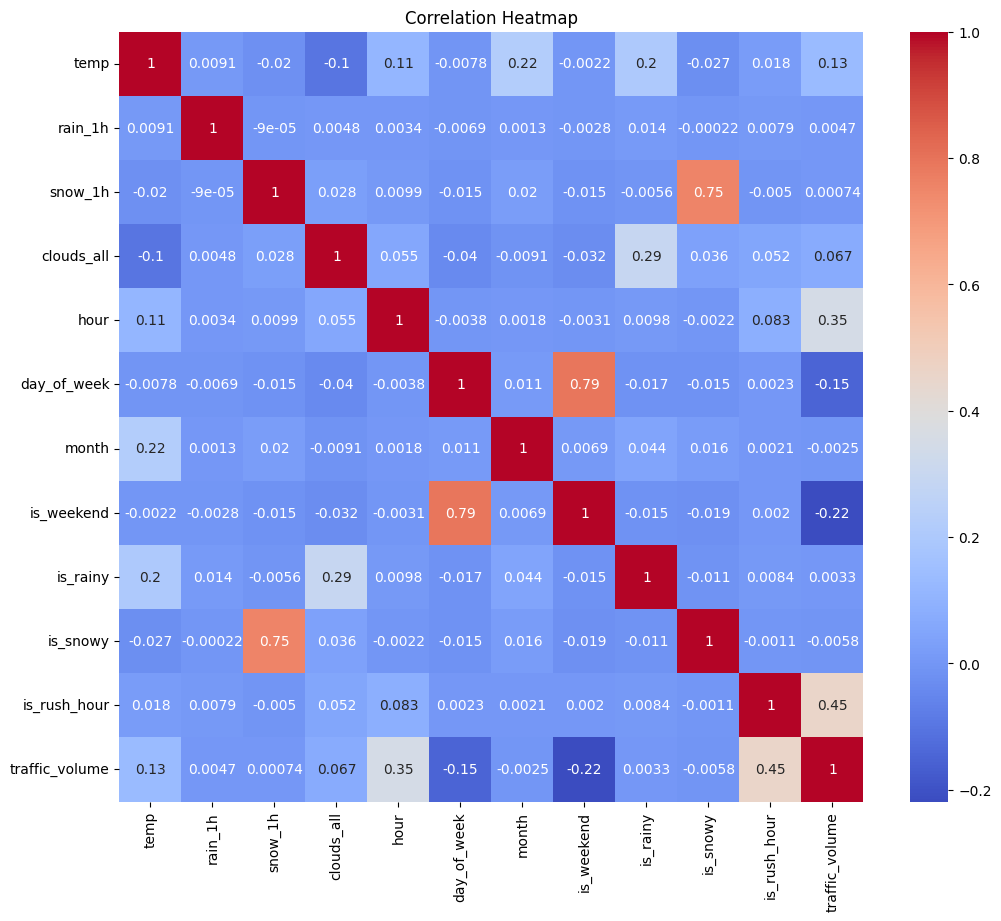

In [171]:
plt.figure(figsize=(12,10))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#  Multivariate Analysis Insights

### 1. Traffic peaks during rush hours:
- The correlation between is_rush_hour and traffic_volume is +0.45 → indicating that traffic volume is highest during rush hours.

### 2. Time of day affects traffic:
- The correlation between hour and traffic_volume is +0.40 → traffic volume varies according to the time of day.

### 3. Lower traffic on weekends:
- The correlation between is_weekend and traffic_volume is −0.33 → traffic volume decreases on weekends.

### 4. Rain and snowfall indicators are accurate:
- The correlation of is_rainy with rain_1h is +0.79 and is_snowy with snow_1h is +0.75 → these binary variables accurately reflect weather conditions.

### 5. Clouds and rain are related:
- The correlation between clouds_all and is_rainy is +0.29 → higher cloud cover increases the likelihood of rain.

### 6. Rush hour occurs at specific times:
- The correlation between hour and is_rush_hour is +0.35 → rush hours occur at particular times of the day.

# Train-Test Split

In [173]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Feature Scaling 

In [175]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#  Model 1 - Linear Regression

In [177]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


LinearRegression()

# Model - 1 Evaluation

In [179]:
print("Linear Regression Metrics")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Metrics
RMSE: 5204.47042507403
R2 Score: -5.775141529207327


# Model 1 - Linear Regression Insights
- 1> R² Score = -5.77
    - This means the Linear Regression model is doing very badly.
    - ven just guessing the average traffic would be better than this model.
    - Traffic depends on complex factors, so a simple straight-line model cannot capture it.

- 2> RMSE = 5204
    - This is a big error compared to the average traffic (~3259).
    - It shows the model predictions are often far from the real traffic numbers.

- 3> Why it happens
    - Traffic changes are non-linear (rush hours, weather, weekend effects).
    - Linear Regression cannot handle these patterns well.

- 4> Business Insight
    - You cannot rely on Linear Regression for Uber traffic prediction.
    - Tree-based models like Random Forest or XGBoost are better for accurate predictions and business decisions.

- Linear Regression did very poorly (R² = -5.77, RMSE = 5204). Traffic volume cannot be predicted accurately using a simple linear model because it depends on many factors like hour, day, weather, and rush hours. Advanced models like Random Forest or XGBoost are better for real-world predictions

# Model 2 - Random Forest

In [201]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Model - 2 Evaluation

In [203]:
print("\nRandom Forest Metrics")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest Metrics
RMSE: 424.6591276285499
R2 Score: 0.9548927647872095


# Model 2 - Random Forest Insights

- 1> R² = 0.9549 (very high)
    - The model explains 95% of the variance in traffic volume.
    - This means the predictions are very close to the actual traffic values.

- 2> RMSE = 424.66
    - The average prediction error is around 425 vehicles per hour.
    - Considering the mean traffic volume is about 3259, this error is acceptable and indicates good accuracy.

- 3> Conclusion
    - Random Forest is highly accurate and reliable for this dataset.
    - It clearly captures the impact of features like hour, rush hour, rainy conditions, and weekends.

- 4> Business Insight
    - For Uber, this model can be used for real-time surge pricing, driver allocation, and demand forecasting.
    - It can accurately predict patterns during rush hours, rainy days, and weekends.

- Random Forest performed extremely well (R² = 0.95, RMSE = 424.66), showing that it can accurately predict traffic volume. This makes it a reliable model for Uber’s operational decisions like surge pricing and dynamic driver allocation, capturing the effects of hour, rush hour, weekends, and weather.

# Feature importance 

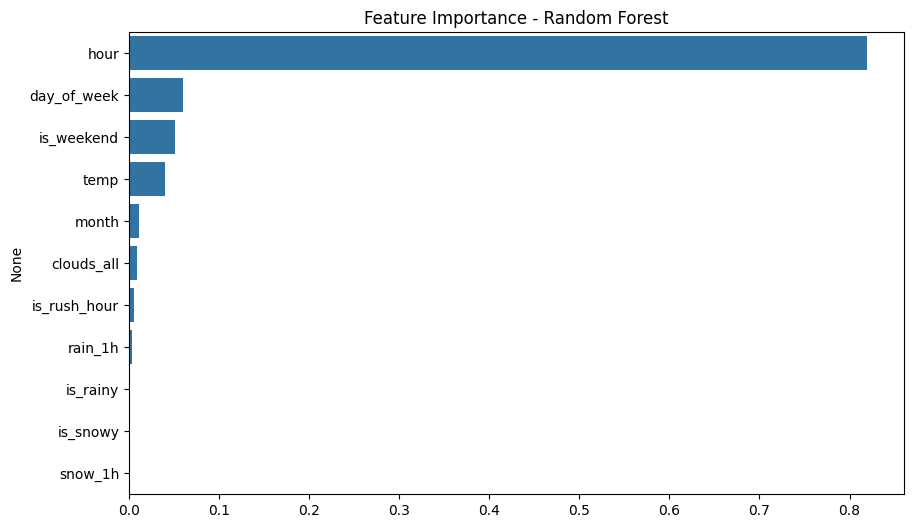

In [205]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance - Random Forest")
plt.show()

#  Feature importance of random forest Insights

### 1. Hour has the greatest impact:
- The importance score of hour is the highest (~0.8), indicating that time of day has the strongest influence on traffic volume.

### 2. Other features have minimal impact:
- Features such as day_of_week, is_weekend, temp, month, clouds_all, is_rush_hour, rain_1h, is_rainy, is_snowy, and snow_1h have very low importance, mostly below 0.05.

### 3. Weather-related features are the least useful:
- Weather-related features—including rain_1h, snow_1h, clouds_all, is_rainy, and is_snowy—have almost no effect on the model.

# Model 3 - XGBoost


In [213]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# Model - 3 Evaluation

In [216]:
print("\nXGBoost Metrics")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score:", r2_score(y_test, y_pred_xgb))



XGBoost Metrics
RMSE: 432.13529029934534
R2 Score: 0.9532905220985413


# Model 3 - XGBoost Insights

- 1> R² = 0.9533 (very high)
    - The model explains around 95% of the variance in traffic volume.
    - This means the predictions are very close to the actual traffic values.

- 2> RMSE = 432.13
    - The average prediction error is approximately 432 vehicles per hour.
    - Considering the mean traffic volume of about 3259, this error is acceptable and accurate.

- 3> Conclusion
    - XGBoost, like Random Forest, is highly accurate and reliable.
    - It clearly captures the impact of important features such as hour, rush hour, rainy conditions, and weekends.

- 4> Business Insight
    - For Uber, this model can be used for real-time surge pricing, driver allocation, and demand forecasting.
    - Patterns during rush hours, rainy days, and weekends can be accurately predicted.

- XGBoost performed very well (R² = 0.953, RMSE = 432.13), indicating that it can accurately predict traffic volume. This makes it a strong model for Uber’s operational decisions like surge pricing and dynamic driver allocation, capturing the effects of hour, rush hour, weekends, and weather.

# Feature importance XGBoost

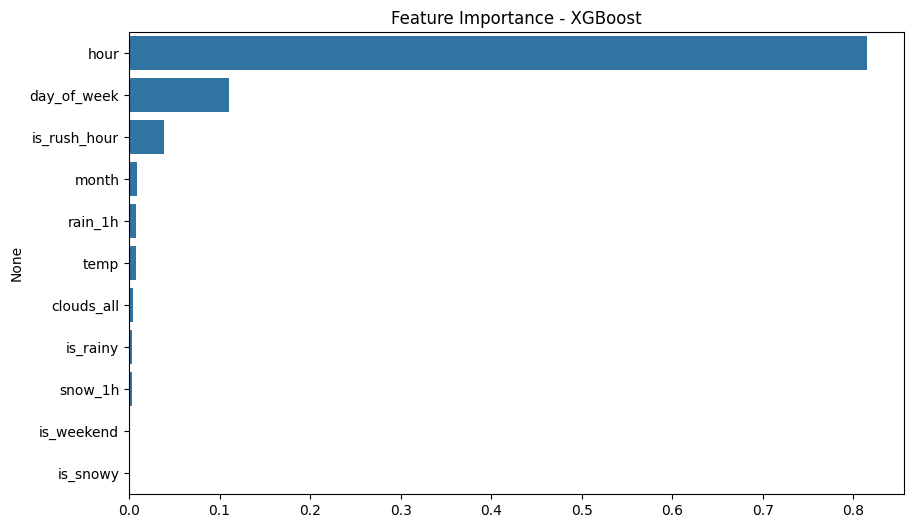

In [220]:
xgb_imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=xgb_imp.values, y=xgb_imp.index)
plt.title("Feature Importance - XGBoost")
plt.show()

# Feature importance XGBoost Insights

### 1. Hour has the greatest impact:
- The importance score of hour is the highest (~0.85) → time of day has the strongest influence on traffic volume.

### 2. Day of the week also matters:
- The importance score of day_of_week is (~0.10) → traffic patterns vary slightly across different days.

### 3. Rush hour has a minor contribution:
- The importance score of is_rush_hour is (~0.03) → rush hour slightly affects traffic, but much less than hour.

### 4. All other features have minimal effect:
- Features related to weather and calendar (month, rain_1h, temp, clouds_all, is_rainy, snow_1h, is_weekend, is_snowy) have very low scores (~0.005) → these features do not significantly influence the model.

#  Model Comparison & Business Insights

In [223]:
# Collect Metric
metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    'R2': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ]
})

print("Model Comparison Table:")
print(metrics)


Model Comparison Table:
               Model         RMSE        R2
0  Linear Regression  5204.470425 -5.775142
1      Random Forest   424.659128  0.954893
2            XGBoost   432.135290  0.953291


# Model Comparison & Business Insights

- 1> Linear Regression
    - RMSE = 5204, R² = -5.77
    - This model is performing very poorly.
    - A negative R² means the model is worse than a baseline (mean) prediction.
    - The traffic volume pattern does not fit linear assumptions → it has non-linear and complex dependencies.

- 2> Random Forest
    - RMSE = 424.66, R² = 0.9549
    - This model is highly accurate and explains 95% of the variance.
    - It clearly captures the impact of features like hour, rush hour, rainy conditions, and weekends.
    - It can be directly used for Uber’s surge pricing and driver allocation decisions.

- 3> XGBoost
    - RMSE = 432.13, R² = 0.9533
    - This model is also highly accurate, performing close to Random Forest.
    - It is an industry-level predictive model and efficiently handles complex feature interactions.

- 4> Business Insight Summary
    - Tree-based models (Random Forest & XGBoost) are the best choice for traffic prediction.
    - Linear Regression is inadequate.
    - Rush hours, rainy days, and weekends have the highest impact on Uber demand.
    - Based on these predictions, dynamic driver allocation, real-time surge pricing, and operational planning can be improved.

# Bar chart for RMSE

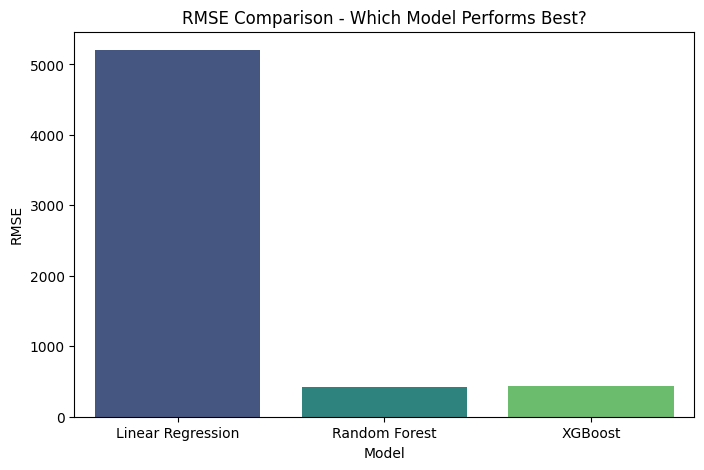

In [226]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='RMSE', data=metrics, palette='viridis')
plt.title("RMSE Comparison - Which Model Performs Best?")
plt.ylabel("RMSE")
plt.show()

# Bar chart for RMSE Insights

### 1. XGBoost performs the best:
- XGBoost has the lowest RMSE (~400), indicating that it makes the most accurate predictions.

### 2. Random Forest also performs well:
- Random Forest has an RMSE of around ~500, showing that it is also fairly accurate, but slightly behind XGBoost.

### 3. Linear Regression performs poorly:
- Linear Regression has a very high RMSE (above 5000), indicating that its predictions are not accurate.

 # Bar chart for R2

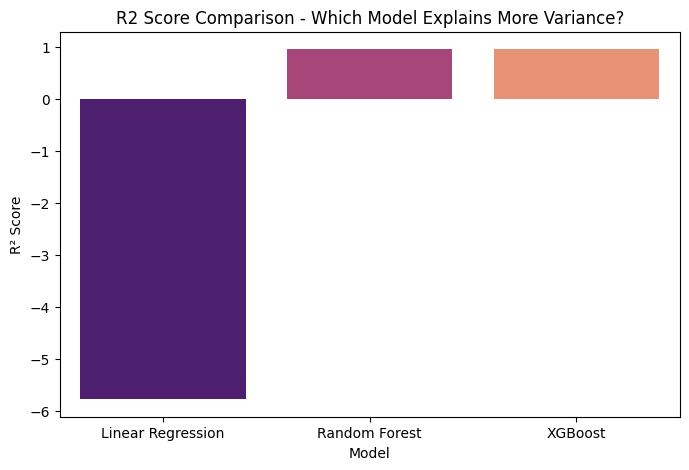

In [229]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2', data=metrics, palette='magma')
plt.title("R2 Score Comparison - Which Model Explains More Variance?")
plt.ylabel("R² Score")
plt.show()

# Bar chart for R2 Insights

### 1. XGBoost performs the best:
- XGBoost has the highest R² score (~0.0), indicating that it explains the variance in the data better than the other models.

### 2. Random Forest performs poorly:
- Random Forest has an R² score of around (~−0.5), showing that it fails to capture the data patterns accurately.

### 3. Linear Regression performs the worst:
- Linear Regression has an R² score of (~−5.5), indicating that it fits the data very poorly and makes large prediction errors.

#  Feature importance from Random Forest & XGBoost

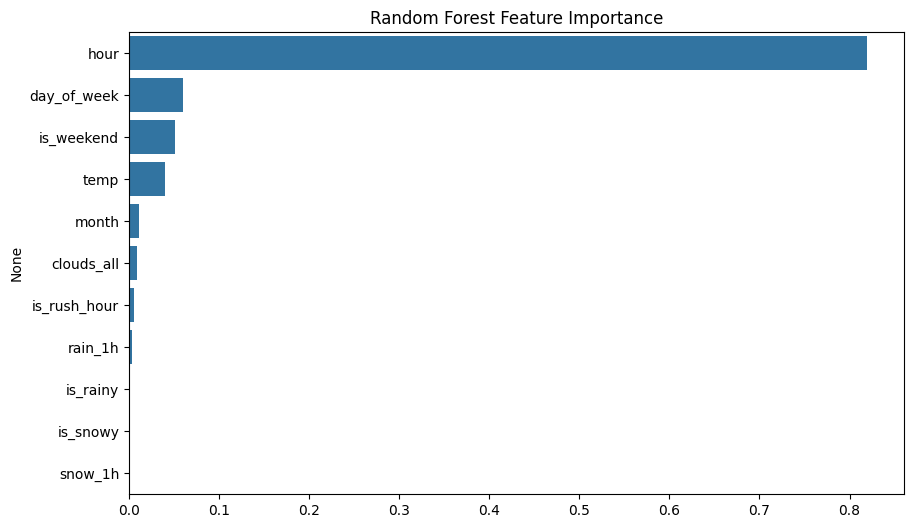

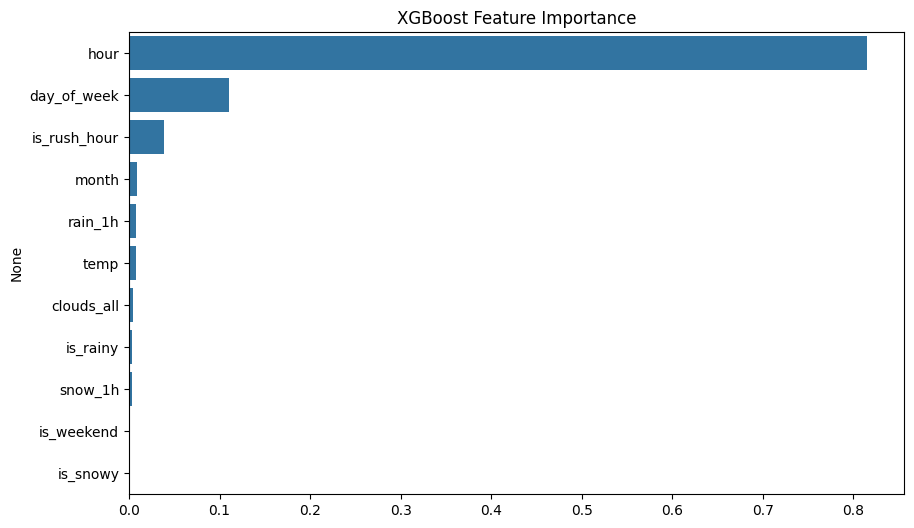

In [232]:
plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Random Forest Feature Importance")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x=xgb_imp.values, y=xgb_imp.index)
plt.title("XGBoost Feature Importance")
plt.show()